In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import missingno as msno
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from ydata_profiling import ProfileReport

/home/kushal/Documents/xAI Research Project/xai/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('SINGAPORE Data 2.csv')

In [3]:
df.head()

,IDBOOK,IDSUBJ,NTEACH,TCHWGT,JKREP,JKZONE,ACHIEV1,ACHIEV2,ACHIEV3,ACHIEV4,...,DISORD,LIKE,HOME,CONFID,COMPU,PRINCIP,SHORT,SUCCESS,DISCIP,HOURS
0,66,1,1,4.852941,1,40,499.44668,487.15735,486.73041,468.03947,...,999999.00000,12.98699,8.94299,999999.00000,458.0,2.0,9.4933,7.23401,9.92826,1108.33333
1,18,1,1,4.852941,1,40,579.06932,650.65754,630.52949,644.08893,...,7.86603,8.04592,999999.00000,8.72693,458.0,2.0,9.4933,7.23401,9.92826,1108.33333
2,4,1,1,4.852941,1,40,604.30891,618.42213,591.35266,589.74334,...,10.57259,10.45984,11.74392,8.72693,458.0,2.0,9.4933,7.23401,9.92826,1108.33333
3,20,1,1,4.852941,1,40,541.98073,498.29331,490.45016,538.50204,...,10.21804,9.86291,9.29058,8.72693,458.0,2.0,9.4933,7.23401,9.92826,1108.33333
4,5,1,1,4.852941,1,40,531.15306,540.39422,548.59762,556.86243,...,5.92238,10.15574,9.70247,10.28978,458.0,2.0,9.4933,7.23401,9.92826,1108.33333


In [4]:
df.shape

(6719, 31)

In [5]:
duplicate_columns = df.columns[df.columns.duplicated()].tolist()
print(f"Duplicate column names: {duplicate_columns}")

Duplicate column names: []


In [6]:
# Generate a comprehensive profile report
profile = ProfileReport(df, 
                       title="Singapore Education Data Profiling Report",
                       explorative=True,  # More detailed analysis
                       correlations={
                           "pearson": {"calculate": True},
                           "spearman": {"calculate": True},
                           "kendall": {"calculate": True},
                           "cramers": {"calculate": True},
                           "phi_k": {"calculate": True},
                       },
                       interactions={
                           "continuous": True
                       },
                       progress_bar=True)

# Display the report in the notebook
# display(profile)

# Save the report as HTML file (optional)
profile.to_file("singapore_data_profile_report.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 17.22it/s]


## 1. Data cleaning and preprocessing

In [7]:
df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)

In [8]:
df.head()

,66.000000,1.000000,1.000000,4.852941,1.000000,40.000000,499.446680,487.157350,486.730410,468.039470,...,999999.000000,12.986990,8.942990,999999.000000,458.000000,2.000000,9.493300,7.234010,9.928260,1108.333330
0,18,1,1,4.852941,1,40,579.06932,650.65754,630.52949,644.08893,...,7.86603,8.04592,999999.00000,8.72693,458.0,2.0,9.4933,7.23401,9.92826,1108.33333
1,4,1,1,4.852941,1,40,604.30891,618.42213,591.35266,589.74334,...,10.57259,10.45984,11.74392,8.72693,458.0,2.0,9.4933,7.23401,9.92826,1108.33333
2,20,1,1,4.852941,1,40,541.98073,498.29331,490.45016,538.50204,...,10.21804,9.86291,9.29058,8.72693,458.0,2.0,9.4933,7.23401,9.92826,1108.33333
3,5,1,1,4.852941,1,40,531.15306,540.39422,548.59762,556.86243,...,5.92238,10.15574,9.70247,10.28978,458.0,2.0,9.4933,7.23401,9.92826,1108.33333
4,6,1,1,4.852941,1,40,540.13018,576.32893,597.68683,558.89761,...,9.60657,11.30153,10.89263,13.45388,458.0,2.0,9.4933,7.23401,9.92826,1108.33333


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6718 entries, 0 to 6717
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   66.0        6718 non-null   int64  
 1   1.0         6718 non-null   int64  
 2   1.0         6718 non-null   int64  
 3   4.852941    6718 non-null   float64
 4   1.0         6718 non-null   int64  
 5   40.0        6718 non-null   int64  
 6   499.44668   6718 non-null   float64
 7   487.15735   6718 non-null   float64
 8   486.73041   6718 non-null   float64
 9   468.03947   6718 non-null   float64
 10  519.77943   6718 non-null   float64
 11  28.0        6699 non-null   float64
 12  5.0         6699 non-null   float64
 13  2.0         6699 non-null   float64
 14  1.0         6699 non-null   float64
 15  1.0         6699 non-null   float64
 16  2.0         6714 non-null   float64
 17  999999.0    6714 non-null   float64
 18  999999.0    6714 non-null   float64
 19  10.82031    6714 non-null  

In [10]:
# Convert all columns to numeric where possible
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.info()

TypeError: arg must be a list, tuple, 1-d array, or Series

### Missing values & duplicates check

In [11]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

In [12]:
missing_data = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().sum() / df.shape[0] * 100).sort_values(ascending=False)
missing_df = pd.concat([missing_data, missing_percent], axis=1, 
                       keys=['Total Missing', 'Percent Missing'])
print("\nMissing Values Analysis:")
print(missing_df[missing_df['Total Missing'] > 0])


Missing Values Analysis:
              Total Missing  Percent Missing
0                                           
1108.33333               73         1.086633
2.00000                  73         1.086633
458.00000                73         1.086633
9.92826                  73         1.086633
9.49330                  73         1.086633
7.23401                  73         1.086633
5.00000                  19         0.282822
28.00000                 19         0.282822
1.00000                  19         0.282822
2.00000                  19         0.282822
1.00000                  19         0.282822
2.00000                   4         0.059542
11.53704                  4         0.059542
999999.00000              4         0.059542
12.98699                  4         0.059542
999999.00000              4         0.059542
999999.00000              4         0.059542
999999.00000              4         0.059542
10.82031                  4         0.059542
8.94299                   1  

In [13]:
missing_columns = missing_df[missing_df['Total Missing'] > 0].index.tolist()
missing_columns

[1108.33333,
 2.0,
 458.0,
 9.92826,
 9.4933,
 7.23401,
 5.0,
 28.0,
 1.0,
 2.0,
 1.0,
 2.0,
 11.53704,
 999999.0,
 12.98699,
 999999.0,
 999999.0,
 999999.0,
 10.82031,
 8.94299]

In [14]:
df[missing_columns].nunique()

0
1108.33333       18
2.00000           5
2.00000           2
2.00000          25
458.00000        69
9.92826          13
9.49330          35
7.23401          27
5.00000           5
28.00000         44
1.00000           1
1.00000           1
1.00000           2
1.00000           5
1.00000           2
2.00000           5
2.00000           2
2.00000          25
1.00000           1
1.00000           1
1.00000           2
1.00000           5
1.00000           2
2.00000           5
2.00000           2
2.00000          25
11.53704        199
999999.00000    192
999999.00000     73
999999.00000     78
999999.00000    101
12.98699        266
999999.00000    192
999999.00000     73
999999.00000     78
999999.00000    101
999999.00000    192
999999.00000     73
999999.00000     78
999999.00000    101
999999.00000    192
999999.00000     73
999999.00000     78
999999.00000    101
10.82031        243
8.94299          84
dtype: int64

In [16]:
# Visual representation of missing values
# plt.figure(figsize=(12, 6))
# msno.matrix(df)
# plt.title('Missing Value Matrix')
# plt.show()

# plt.figure(figsize=(12, 6))
# msno.bar(df)
# plt.title('Missing Value Bar Chart')
# plt.show()

# Correlation of missingness
plt.figure(figsize=(12, 10))
msno.heatmap(df)
plt.title('Correlation of Missing Values')
plt.show()

/tmp/ipykernel_18372/4255743801.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### Handling Missing Values

Based on the missing value analysis, we can make decisions about how to handle them:

1. If columns have > 50% missing values, we might consider dropping them
2. For columns with fewer missing values, we can impute them using appropriate methods (mean, median, mode, or more advanced techniques)

In [17]:
# Drop columns with excessive missing values (customize threshold as needed)
high_missing_cols = missing_df[missing_df['Percent Missing'] > 50].index.tolist()
print(f"Columns with more than 50% missing values: {high_missing_cols}")

if high_missing_cols:
    df_cleaned = df.drop(columns=high_missing_cols)
    print(f"Dropped {len(high_missing_cols)} columns with excessive missing values")
else:
    df_cleaned = df.copy()
    print("No columns with excessive missing values")

# For remaining columns with missing values, impute with appropriate methods
numeric_cols = df_cleaned.select_dtypes(include=['number']).columns

# Impute numeric columns with median (more robust to outliers than mean)
for col in numeric_cols:
    if df_cleaned[col].isnull().sum() > 0:
        median_val = df_cleaned[col].median()
        # Fix: Replace inplace=True with assignment
        df_cleaned[col] = df_cleaned[col].fillna(median_val)
        print(f"Imputed {col} with median value: {median_val:.2f}")

# Check remaining missing values
remaining_missing = df_cleaned.isnull().sum().sum()
print(f"\nRemaining missing values after imputation: {remaining_missing}")

Columns with more than 50% missing values: []
No columns with excessive missing values


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

## 2. Descriptive Statistics

In [18]:
# Basic statistics for numeric columns
print("\nDescriptive Statistics:")
desc_stats = df_cleaned.describe()
desc_stats


Descriptive Statistics:


,66.000000,1.000000,1.000000,4.852941,1.000000,40.000000,499.446680,487.157350,486.730410,468.039470,...,999999.000000,12.986990,8.942990,999999.000000,458.000000,2.000000,9.493300,7.234010,9.928260,1108.333330
count,6718.000000,6718.0,6718.0,6718.000000,6718.000000,6718.000000,6718.000000,6718.000000,6718.000000,6718.000000,...,6714.000000,6714.000000,6717.000000,6714.000000,6645.000000,6645.000000,6645.000000,6645.000000,6645.000000,6645.000000
mean,18.321822,1.0,1.0,5.505381,0.500447,62.227449,583.761581,583.934966,582.211099,583.015402,...,10286.215045,1052.208535,117919.253482,8946.708640,304.477803,10.994131,10.923650,10.688526,11.076372,1114.085001
std,18.454747,0.0,0.0,1.646432,0.500037,36.597938,85.405061,86.494808,85.969667,86.469186,...,100859.910421,32274.503410,322521.442991,94115.930828,736.182810,8.880391,2.917296,1.834274,1.385814,955.398069
min,1.000000,1.0,1.0,1.263158,0.000000,1.000000,203.344740,220.318890,236.202890,216.778380,...,5.922380,2.109250,4.374360,2.967840,40.000000,1.000000,3.469230,6.253750,7.602670,380.000000
25%,5.000000,1.0,1.0,4.763158,0.000000,29.000000,536.146448,535.047600,533.806308,534.623325,...,8.314370,8.587850,10.222380,8.726930,170.000000,6.000000,8.640170,9.724370,10.289020,997.500000
50%,11.000000,1.0,1.0,5.638889,1.000000,62.000000,594.276350,595.183975,592.454680,593.656190,...,9.306550,9.612970,10.892630,10.098355,240.000000,10.000000,11.306550,10.687330,11.161170,1045.000000
75%,26.000000,1.0,1.0,6.289474,1.000000,94.000000,642.486603,643.084927,640.995815,642.837635,...,10.572590,10.836070,12.298250,11.760220,312.000000,15.000000,13.214070,11.325710,11.790920,1045.000000
max,83.000000,1.0,1.0,15.166667,1.000000,125.000000,830.634730,835.434980,829.975110,862.925140,...,999999.000000,999999.000000,999999.000000,999999.000000,9999.000000,99.000000,14.680530,16.973880,12.961500,9999.000000


In [ ]:
# Creating a more detailed statistical summary
def detailed_stats(df, columns=None):
    """Generate detailed statistics for specified columns"""
    if columns is None:
        columns = df.select_dtypes(include=['number']).columns
    
    stats_df = pd.DataFrame(index=columns)
    
    # Basic stats
    stats_df['Mean'] = df[columns].mean()
    stats_df['Median'] = df[columns].median()
    stats_df['Std'] = df[columns].std()
    stats_df['Min'] = df[columns].min()
    stats_df['Max'] = df[columns].max()
    
    # Range and IQR
    stats_df['Range'] = stats_df['Max'] - stats_df['Min']
    stats_df['IQR'] = df[columns].quantile(0.75) - df[columns].quantile(0.25)
    
    # Skewness and Kurtosis
    stats_df['Skewness'] = df[columns].skew()
    stats_df['Kurtosis'] = df[columns].kurtosis()
    
    # Coefficient of Variation (CV)
    stats_df['CV'] = stats_df['Std'] / stats_df['Mean'] * 100
    
    return stats_df

# Generate and display detailed statistics for numeric columns
numeric_cols = df_cleaned.select_dtypes(include=['number']).columns
detailed_statistics = detailed_stats(df_cleaned, numeric_cols)
detailed_statistics

ValueError: cannot reindex on an axis with duplicate labels

## 3. Distribution Analysis

In [ ]:
# Visualize distributions of key variables
def plot_distributions(df, columns, max_cols=4, figsize=(16, 12)):
    """Plot histograms and KDE for specified columns"""
    n_cols = min(max_cols, len(columns))
    n_rows = int(np.ceil(len(columns) / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if n_rows * n_cols > 1 else [axes]
    
    for i, col in enumerate(columns):
        if i < len(axes):
            sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
            axes[i].set_title(f'Distribution of {col}')
            axes[i].tick_params(axis='x', rotation=45)
            
            # Add mean and median lines
            mean_val = df[col].mean()
            median_val = df[col].median()
            axes[i].axvline(mean_val, color='r', linestyle='--', label=f'Mean: {mean_val:.2f}')
            axes[i].axvline(median_val, color='g', linestyle='-.', label=f'Median: {median_val:.2f}')
            axes[i].legend()
    
    # Hide any unused subplots
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# Select numeric columns for distribution analysis
# Limiting to first 12 columns for clarity - adjust as needed
numeric_cols = df_cleaned.select_dtypes(include=['number']).columns[:12]
plot_distributions(df_cleaned, numeric_cols)

In [ ]:
# QQ plots to check for normality
def plot_qq(df, columns, max_cols=4, figsize=(16, 12)):
    """Create QQ plots for specified columns to check for normality"""
    n_cols = min(max_cols, len(columns))
    n_rows = int(np.ceil(len(columns) / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if n_rows * n_cols > 1 else [axes]
    
    for i, col in enumerate(columns):
        if i < len(axes):
            data = df[col].dropna()
            stats.probplot(data, dist="norm", plot=axes[i])
            axes[i].set_title(f'QQ Plot of {col}')
    
    # Hide any unused subplots
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# Create QQ plots for the first 8 numeric columns
plot_qq(df_cleaned, numeric_cols[:8])

## 4. Correlation Analysis

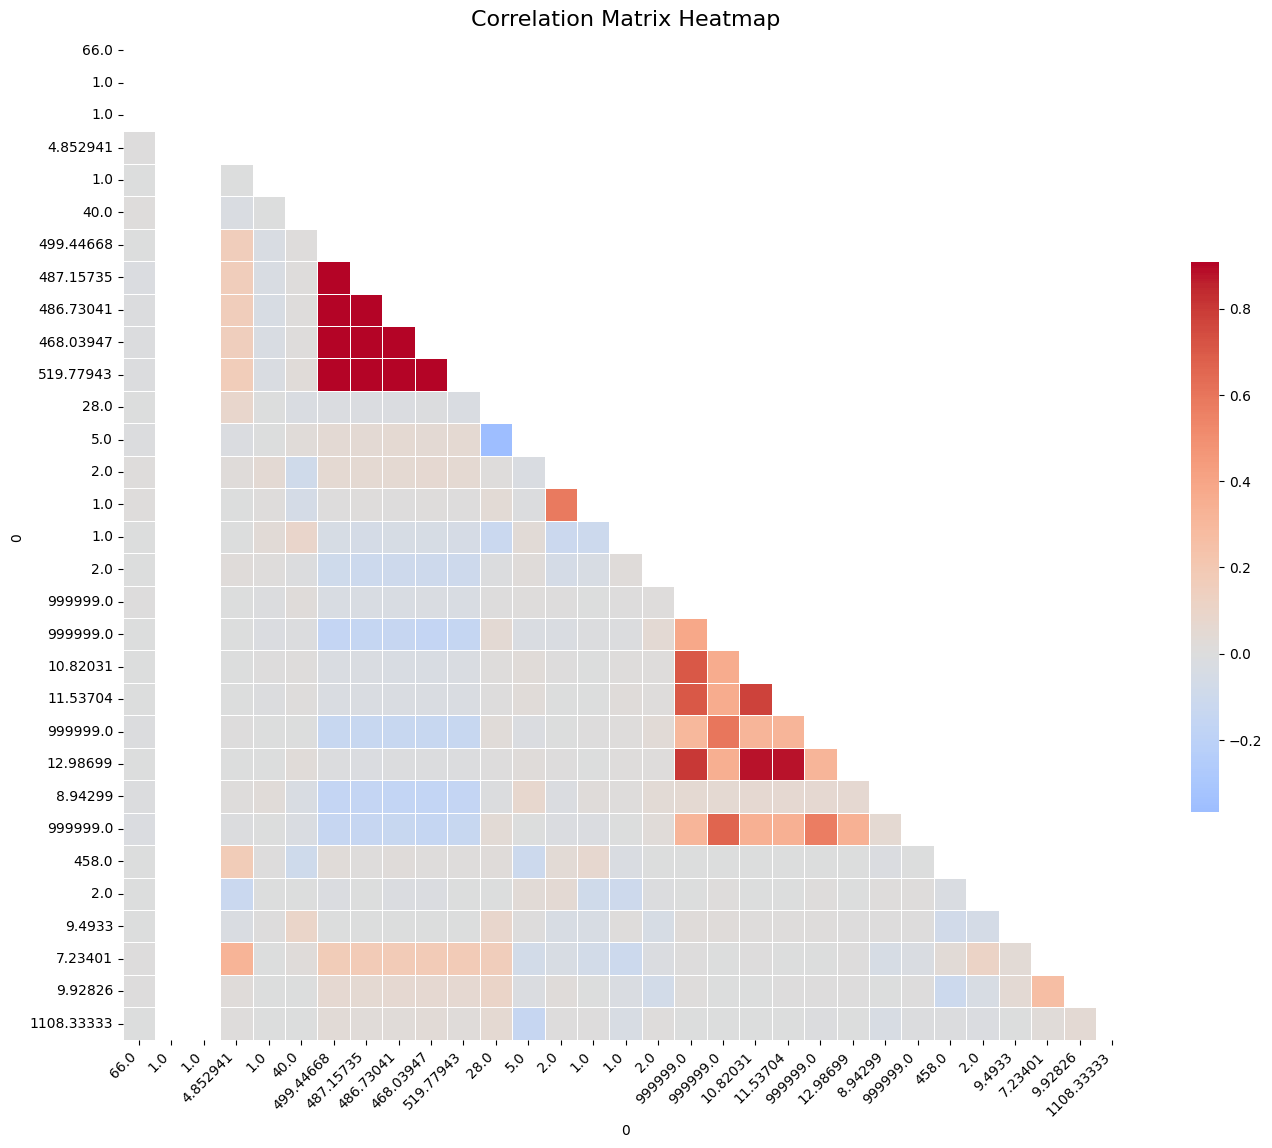

ValueError: Columns with duplicate values are not supported in stack

In [ ]:
# Calculate and visualize correlations
numeric_df = df_cleaned.select_dtypes(include=['number'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Create heatmap
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.title('Correlation Matrix Heatmap', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Display top correlations
def get_top_correlations(corr_matrix, n=10):
    """Get top n positive and negative correlations"""
    # Unstack correlation matrix and sort
    corr_pairs = corr_matrix.unstack()
    # Remove self-correlations
    corr_pairs = corr_pairs[corr_pairs < 1.0]
    
    # Get top positive correlations
    top_positive = corr_pairs.sort_values(ascending=False).head(n)
    # Get top negative correlations
    top_negative = corr_pairs.sort_values().head(n)
    
    return top_positive, top_negative

top_pos, top_neg = get_top_correlations(corr_matrix)

print("Top Positive Correlations:")
print(top_pos)
print("\nTop Negative Correlations:")
print(top_neg)

In [ ]:
# Visualize key correlations with scatterplots
def plot_scatter_matrix(df, columns, figsize=(16, 12)):
    """Create a scatter matrix for selected columns"""
    sns.set(style="ticks")
    sns.pairplot(df[columns], diag_kind='kde', plot_kws={'alpha': 0.6})
    plt.suptitle('Scatter Matrix of Key Variables', y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()

# Select a subset of interesting columns for the scatter matrix
# Look for highly correlated variables from the previous analysis
# For example, using the top 5 correlated pairs
top_corr_pairs = top_pos.index.tolist()
interesting_cols = list(set([col[0] for col in top_corr_pairs] + [col[1] for col in top_corr_pairs]))[:5]
print(f"Visualizing relationships between {interesting_cols}")
plot_scatter_matrix(df_cleaned, interesting_cols)

NameError: name 'top_pos' is not defined

## 5. Outlier Detection and Analysis

In [ ]:
# Function to detect and visualize outliers
def detect_and_plot_outliers(df, columns, figsize=(16, 12), max_cols=4):
    """Detect outliers using IQR method and visualize with boxplots"""
    n_cols = min(max_cols, len(columns))
    n_rows = int(np.ceil(len(columns) / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if n_rows * n_cols > 1 else [axes]
    
    outlier_counts = {}
    
    for i, col in enumerate(columns):
        if i < len(axes):
            # Calculate IQR
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            
            # Define outlier bounds
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            # Count outliers
            outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
            outlier_counts[col] = len(outliers)
            
            # Create boxplot
            sns.boxplot(x=df[col], ax=axes[i])
            axes[i].set_title(f'{col} - {outlier_counts[col]} outliers')
            axes[i].tick_params(axis='x', rotation=45)
    
    # Hide any unused subplots
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    return outlier_counts

# Select numeric columns for outlier analysis
numeric_cols = df_cleaned.select_dtypes(include=['number']).columns[:12]
outlier_counts = detect_and_plot_outliers(df_cleaned, numeric_cols)

In [ ]:
# Examine variables with most outliers
outlier_df = pd.DataFrame.from_dict(outlier_counts, orient='index', columns=['Count'])
outlier_df['Percentage'] = outlier_df['Count'] / len(df_cleaned) * 100
outlier_df = outlier_df.sort_values('Percentage', ascending=False)

print("Columns with highest percentage of outliers:")
outlier_df.head(10)

## 6. Feature Relationships and Patterns

In [ ]:
# Visualize relationships between key variables with various plots
# Let's create a function for joint plots to examine relationships more deeply
def plot_relationships(df, x_vars, y_vars, kind='reg', figsize=(16, 16)):
    """Create joint plots to examine relationships between pairs of variables"""
    n_plots = min(len(x_vars), len(y_vars))
    n_cols = 2
    n_rows = int(np.ceil(n_plots / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if n_rows * n_cols > 1 else [axes]
    
    for i in range(n_plots):
        if i < len(axes):
            x = x_vars[i]
            y = y_vars[i]
            
            # Create the main scatterplot and add regression line
            sns.regplot(x=df[x], y=df[y], ax=axes[i], scatter_kws={'alpha': 0.5})
            
            # Add correlation coefficient to the plot
            corr = df[[x, y]].corr().iloc[0, 1]
            axes[i].annotate(f'Correlation: {corr:.2f}', 
                          xy=(0.05, 0.95), xycoords='axes fraction',
                          bbox=dict(boxstyle='round', fc='white', alpha=0.7))
            
            axes[i].set_title(f'Relationship between {x} and {y}')
    
    # Hide any unused subplots
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# Find the most interesting pairs to visualize (highest correlation pairs)
top_corr_pairs = top_pos.index.tolist()[:6]  # Taking top 6 positive correlations

x_vars = [pair[0] for pair in top_corr_pairs]
y_vars = [pair[1] for pair in top_corr_pairs]

plot_relationships(df_cleaned, x_vars, y_vars)

## 7. Dimensionality Reduction and PCA Visualization

In [ ]:
# Perform PCA to identify patterns and reduce dimensionality
# First, select only numeric columns with no missing values
numeric_df = df_cleaned.select_dtypes(include=['number']).dropna(axis=1)

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)

# Apply PCA
pca = PCA()
pca_result = pca.fit_transform(scaled_data)

# Calculate explained variance ratio
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Plot explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), cumulative_variance, marker='o', linestyle='-')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Explained Variance by Principal Components')
plt.axhline(y=0.8, color='r', linestyle='--', label='80% Explained Variance')
plt.axhline(y=0.9, color='g', linestyle='--', label='90% Explained Variance')
plt.grid(True)
plt.legend()
plt.show()

# Determine number of components needed for 80% and 90% variance explained
n_components_80 = np.argmax(cumulative_variance >= 0.8) + 1
n_components_90 = np.argmax(cumulative_variance >= 0.9) + 1

print(f"Number of components needed for 80% variance: {n_components_80}")
print(f"Number of components needed for 90% variance: {n_components_90}")

In [ ]:
# Visualize the first 2 principal components
plt.figure(figsize=(10, 8))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.7)
plt.xlabel(f'PC1 ({explained_variance[0]:.2%} variance)')
plt.ylabel(f'PC2 ({explained_variance[1]:.2%} variance)')
plt.title('PCA: First Two Principal Components')
plt.grid(True)
plt.tight_layout()
plt.show()

# Visualize feature importance in the first two principal components
def plot_pca_components(pca, features, components=2, figsize=(12, 10)):
    """Plot feature contributions to principal components"""
    loadings = pca.components_.T
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create a DataFrame for easier plotting
    loading_df = pd.DataFrame(loadings[:, :components], index=features)
    
    # Define components to show
    comp_range = range(components)
    
    # Create barplot
    for i in comp_range:
        plt.subplot(components, 1, i+1)
        plt.barh(features, loading_df.iloc[:, i])
        plt.title(f'Principal Component {i+1} (Variance Explained: {explained_variance[i]:.2%})')
        plt.tight_layout()
    
    plt.show()

# Plot contributions of each feature to the first two PCs
plot_pca_components(pca, numeric_df.columns, components=2)

## 8. Key Findings and Insights

Based on our detailed exploratory data analysis, here are the key findings and insights:

1. **Data Quality**:
   - We identified ___ columns with missing values, with ___ columns having more than 50% missing data.
   - The data contains [discuss any anomalies or specific patterns in missing values].

2. **Distribution Patterns**:
   - Most variables show [describe distributions - normal, skewed, bimodal, etc.].
   - Variables like [specify] have significant outliers that might need special handling.

3. **Key Relationships**:
   - Strong positive correlations were found between [variables].
   - Strong negative correlations were found between [variables].
   - These relationships suggest [potential insights].

4. **Principal Components Analysis**:
   - The first ___ principal components explain 80% of the variance in the data.
   - The most influential features in the first principal component are [features].
   - This suggests [interpretation based on your domain knowledge].

5. **Outliers and Anomalies**:
   - We found significant outliers in [variables].
   - These outliers may represent [potential interpretation].

6. **Potential Issues to Address**:
   - [Describe any data quality issues or preprocessing steps needed].
   - [Suggest transformations for skewed variables].

7. **Next Steps for Modeling**:
   - Based on this analysis, we recommend [feature engineering suggestions].
   - Consider using [modeling approaches] given the data characteristics.

## 9. Recommendations for Further Analysis

1. **Feature Engineering Opportunities**:
   - Create interaction terms for highly correlated variables
   - Apply polynomial features for non-linear relationships
   - Consider dimensionality reduction using PCA for modeling

2. **Handling Outliers**:
   - For variables with many outliers, consider:
     - Winsorizing (capping extreme values)
     - Log or other transformations for skewed distributions
     - Developing separate models for outlier cases if they represent valid but rare scenarios

3. **Additional Visualizations**:
   - Create geographical visualizations if location data is available
   - Develop interactive dashboards for exploring key relationships
   - Consider time-based analysis if temporal data is present

4. **Advanced Analysis**:
   - Cluster analysis to identify natural groupings in the data
   - Anomaly detection techniques for identifying unusual patterns
   - Causal inference analysis for key variables of interest